# 特征工程


## 什么是特征工程？
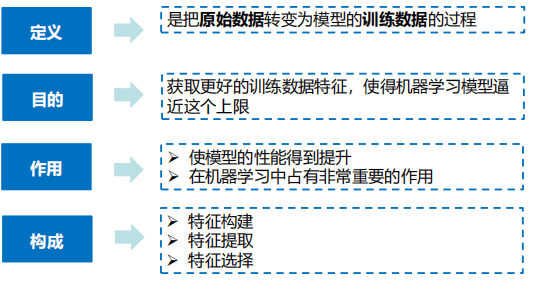

**数据决定一切**
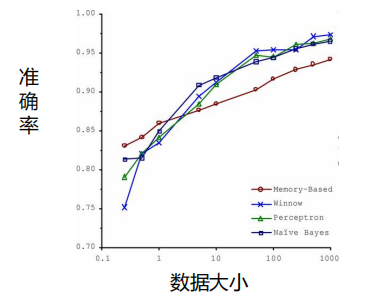


## 为什么需要特征工程(Feature Engineering)


```
机器学习领域的大神Andrew Ng(吴恩达)老师说“Coming up with features is difficult, time-consuming, requires expert knowledge. “Applied machine learning” is basically feature engineering. ”

注：业界广泛流传：数据和特征决定了机器学习的上限，而模型和算法只是逼近这个上限而已。
```


特征工程是使用专业背景知识和技巧处理数据，使得特征能在机器学习算法上发挥更好的作用的过程。

- 意义：会直接影响机器学习的效果

## 特征工程的位置与数据处理的比较
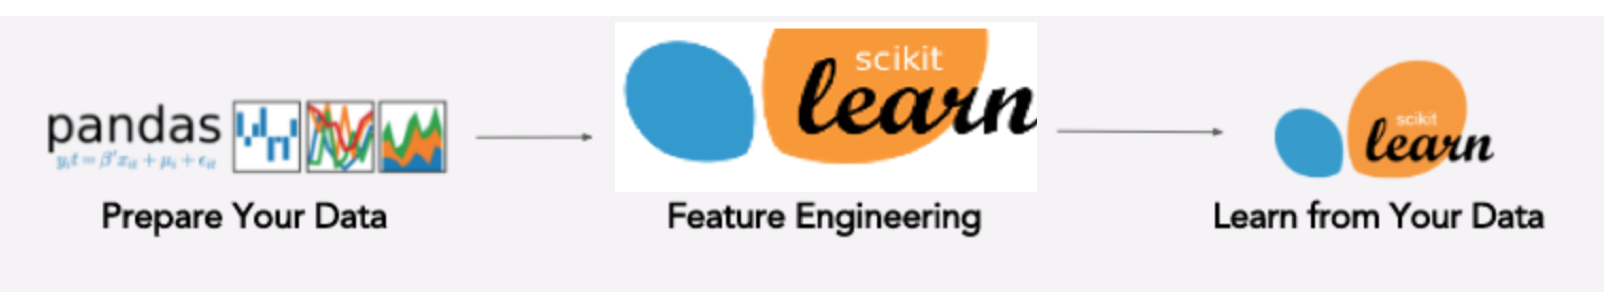
- pandas:一个数据读取非常方便以及基本的处理格式的工具
- sklearn:对于特征的处理提供了强大的接口

### 特征工程包含内容

- 特征抽取
- 特征预处理
- 特征降维

## 特征提取

什么是特征提取呢？

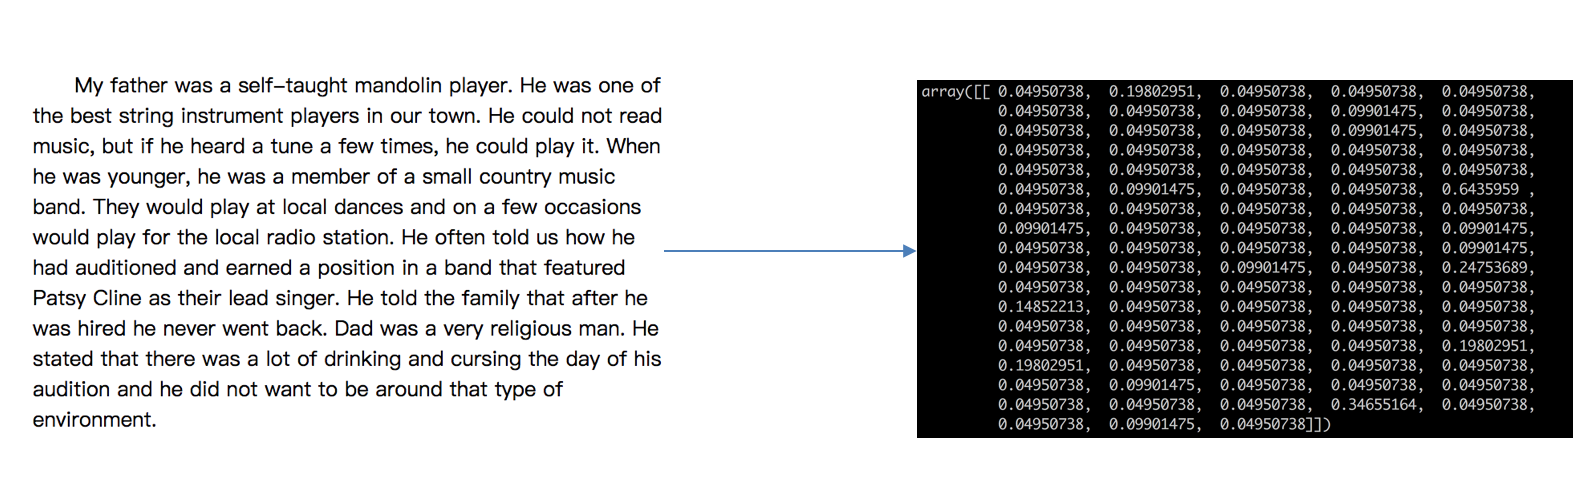

**将任意数据（如文本或图像）转换为可用于机器学习的数字特征**（注：特征值化是为了计算机更好的去理解数据）
- 字典特征提取(特征离散化)
- 文本特征提取
- 图像特征提取（深度学习将介绍）

**特征提取API**
```
sklearn.feature_extraction
```

## 字典特征提取

作用：对字典数据进行特征值化

- sklearn.feature_extraction.DictVectorizer(sparse=True,…)
    - DictVectorizer.fit_transform(X) X:字典或者包含字典的迭代器返回值：返回sparse矩阵
    - DictVectorizer.inverse_transform(X) X:array数组或者sparse矩阵 返回值:转换之前数据格式
    - DictVectorizer.get_feature_names() 返回类别名称
    
### 应用
对以下数据进行特征提取：
```
[{'city': '北京','temperature':100}
{'city': '上海','temperature':60}
{'city': '深圳','temperature':30}]
```

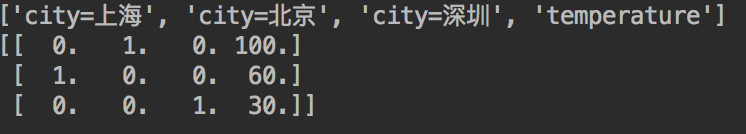

### python 实现
- 实例化类DictVectorizer
- 调用fit_transform方法输入数据并转换（注意返回格式）

In [3]:
from sklearn.feature_extraction import DictVectorizer

def dict_demo():
    """
    对字典类型的数据进行特征抽取
    :return: None
    """
    data = [{'city': '北京','temperature':100}, {'city': '上海','temperature':60}, {'city': '深圳','temperature':30}]
    # 1、实例化一个转换器类
    transfer = DictVectorizer(sparse=False)
    # 2、调用fit_transform
    data = transfer.fit_transform(data)
    print("返回的结果:\n", data)
    # 打印特征名字
    print("特征名字：\n", transfer.get_feature_names())

    return None

In [2]:
dict_demo()

返回的结果:
 [[  0.   1.   0. 100.]
 [  1.   0.   0.  60.]
 [  0.   0.   1.  30.]]
特征名字：
 ['city=上海', 'city=北京', 'city=深圳', 'temperature']


## 文本特征提取

作用：对文本数据进行特征值化

- sklearn.feature_extraction.text.CountVectorizer(stop_words=[])

    - 返回词频矩阵
    
    
    
- CountVectorizer.fit_transform(X) X:文本或者包含文本字符串的可迭代对象 返回值：返回sparse矩阵
- CountVectorizer.inverse_transform(X) X:array数组或者sparse矩阵 返回值:转换之前数据格
- CountVectorizer.get_feature_names() 返回值:单词列表



- **sklearn.feature_extraction.text.TfidfVectorizer**

### 应用（python 实现）
我们对以下数据进行特征提取：
```
["life is short,i like python",
"life is too long,i dislike python"]
```
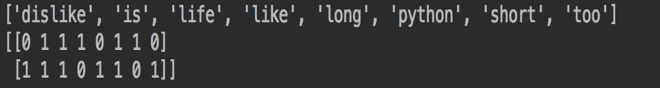

- 实例化类CountVectorizer
- 调用fit_transform方法输入数据并转换 （注意返回格式，利用toarray()进行sparse矩阵转换array数组）

In [23]:
from sklearn.feature_extraction.text import CountVectorizer

def text_count_demo():
    """
    对文本进行特征抽取，countvetorizer
    :return: None
    """
    data = ["life is short,i like python", "life is too long,i dislike python"]
    # 1、实例化一个转换器类
    # transfer = CountVectorizer(sparse=False)
    transfer = CountVectorizer()
    # 2、调用fit_transform
    data = transfer.fit_transform(data)
    print("文本特征抽取的结果：\n", data.toarray())
    print("返回特征名字：\n", transfer.get_feature_names())

    return None

In [24]:
text_count_demo()

文本特征抽取的结果：
 [[0 1 1 1 0 1 1 0]
 [1 1 1 0 1 1 0 1]]
返回特征名字：
 ['dislike', 'is', 'life', 'like', 'long', 'python', 'short', 'too']


### 问题:如果我们将数据替换成中文？
```
"人生苦短，我喜欢Python" "生活太长久，我不喜欢Python"
```

那么最终得到的结果是?

In [12]:
from sklearn.feature_extraction.text import CountVectorizer

def text_count_demo():
    """
    对文本进行特征抽取，countvetorizer
    :return: None
    """
    data = ["人生苦短，我喜欢Python", "生活太长久，我不喜欢Python"]
    # 1、实例化一个转换器类
    # transfer = CountVectorizer(sparse=False)
    transfer = CountVectorizer()
    # 2、调用fit_transform
    data = transfer.fit_transform(data)
    print("文本特征抽取的结果：\n", data.toarray())
    print("返回特征名字：\n", transfer.get_feature_names())

    return None

text_count_demo()

文本特征抽取的结果：
 [[1 0 1 0]
 [0 1 0 1]]
返回特征名字：
 ['人生苦短', '我不喜欢python', '我喜欢python', '生活太长久']


为什么会得到这样的结果呢? 仔细分析之后会发现英文默认是以空格分开的。其实就达到了一个分词的效果，所以我们要对中文进行分词处理!!!

### jieba分词处理

- jieba.cut()
    - 返回词语组成的生成器
    
需要安装下jieba库
```
pip3 install jieba
```

### 中文文本特征提取
- 准备句子，利用jieba.cut进行分词
- 实例化CountVectorizer
- 将分词结果变成字符串当作fit_transform的输入值

In [7]:
! pip install jieba

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple, https://pypi.org/simple, https://mirrors.aliyun.com/pypi/simple/, https://mirror.baidu.com/pypi/simple
  Created wheel for jieba: filename=jieba-0.42.1-py3-none-any.whl size=19314478 sha256=6c29a9e965f2683c081d24b22c1f68bfa89f39f1820c96ea74ac1444a3a46eb8
  Stored in directory: c:\users\administrator\appdata\local\pip\cache\wheels\da\32\88\27de7b74c07183e879d53a8c97dbf4aaff183483941de4236d
Successfully built jieba


In [17]:
from sklearn.feature_extraction.text import CountVectorizer
import jieba

def cut_word(text):
    """
    对中文进行分词
    "我爱北京天安门"————>"我 爱 北京 天安门"
    :param text:
    :return: text
    """
    # 用结巴对中文字符串进行分词
#     print(list(jieba.cut(text)))
    text = " ".join(list(jieba.cut(text)))

    return text

def text_chinese_count_demo2():
    """
    对中文进行特征抽取
    :return: None
    """
#     data = ["人生苦短，我喜欢Python", "生活太长久，我不喜欢Python"]
    data = ["一种还是一种今天很残酷，明天更残酷，后天很美好，但绝对大部分是死在明天晚上，所以每个人不要放弃今天。",
            "我们看到的从很远星系来的光是在几百万年之前发出的，这样当我们看到宇宙时，我们是在看它的过去。",
            "如果只用一种方式了解某样事物，你就不会真正了解它。了解事物真正含义的秘密取决于如何将其与我们所了解的事物相联系。"]
#     data = ["我爱北京天安门"]
    # 将原始数据转换成分好词的形式
    text_list = []
    for sent in data:
        text_list.append(cut_word(sent))
    print(text_list)

    # 1、实例化一个转换器类
#     transfer = CountVectorizer(sparse=False)
    transfer = CountVectorizer()
    # 2、调用fit_transform
    data = transfer.fit_transform(text_list)
    print("文本特征抽取的结果：\n", data.toarray())
    print("返回特征名字：\n", transfer.get_feature_names())

    return None

In [18]:
text_chinese_count_demo2()

['一种 还是 一种 今天 很 残酷 ， 明天 更 残酷 ， 后天 很 美好 ， 但 绝对 大部分 是 死 在 明天 晚上 ， 所以 每个 人 不要 放弃 今天 。', '我们 看到 的 从 很 远 星系 来 的 光是在 几百万年 之前 发出 的 ， 这样 当 我们 看到 宇宙 时 ， 我们 是 在 看 它 的 过去 。', '如果 只用 一种 方式 了解 某样 事物 ， 你 就 不会 真正 了解 它 。 了解 事物 真正 含义 的 秘密 取决于 如何 将 其 与 我们 所 了解 的 事物 相 联系 。']
文本特征抽取的结果：
 [[2 0 1 0 0 0 2 0 0 0 0 0 1 0 1 0 0 0 0 1 1 0 2 0 1 0 2 1 0 0 0 1 1 0 0 1
  0]
 [0 0 0 1 0 0 0 1 1 1 0 0 0 0 0 0 0 1 3 0 0 0 0 1 0 0 0 0 2 0 0 0 0 0 1 0
  1]
 [1 1 0 0 4 3 0 0 0 0 1 1 0 1 0 1 1 0 1 0 0 1 0 0 0 1 0 0 0 2 1 0 0 1 0 0
  0]]
返回特征名字：
 ['一种', '不会', '不要', '之前', '了解', '事物', '今天', '光是在', '几百万年', '发出', '取决于', '只用', '后天', '含义', '大部分', '如何', '如果', '宇宙', '我们', '所以', '放弃', '方式', '明天', '星系', '晚上', '某样', '残酷', '每个', '看到', '真正', '秘密', '绝对', '美好', '联系', '过去', '还是', '这样']


**但如果把这样的词语特征用于分类，会出现什么问题？**
请看问题：
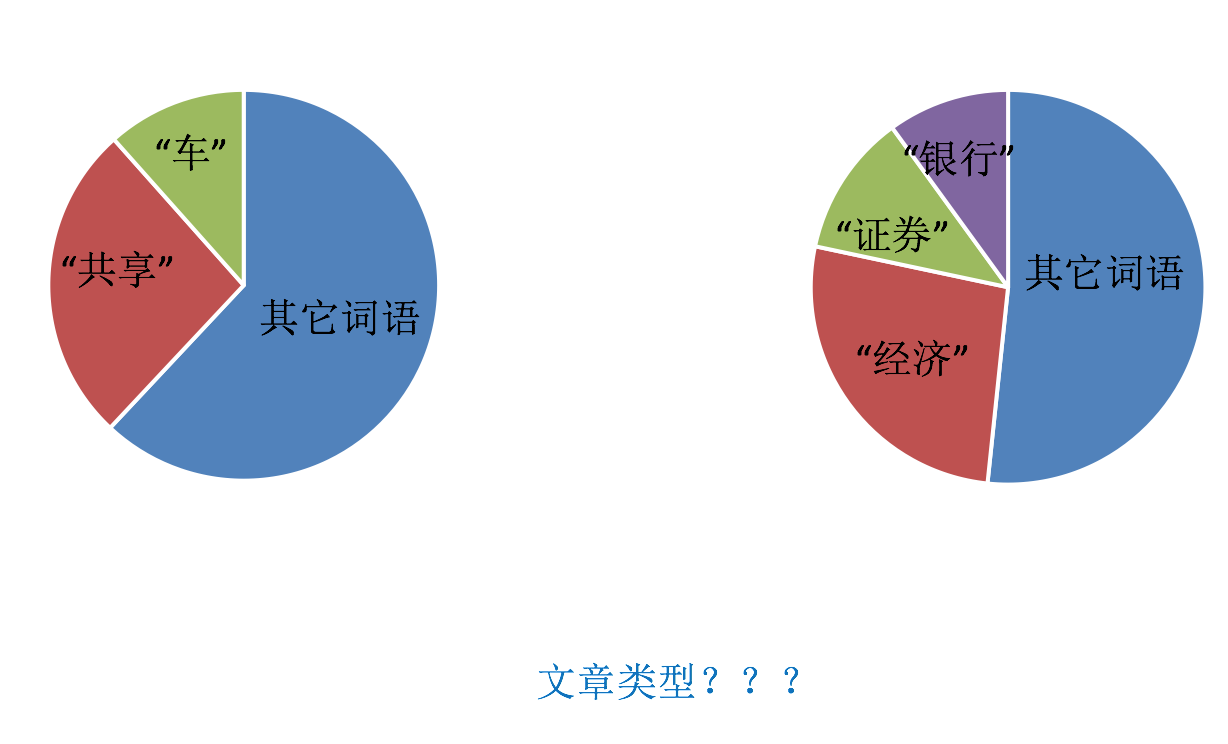

**该如何处理某个词或短语在多篇文章中出现的次数高这种情况**

### Tf-idf文本特征提取
- TF-IDF的主要思想是：如果某个词或短语在一篇文章中出现的概率高，并且在其他文章中很少出现，则认为此词或者短语具有很好的类别区分能力，适合用来分类。
- TF-IDF作用：用以评估一字词对于一个文件集或一个语料库中的其中一份文件的重要程度。

**公式**
- 词频（term frequency，tf）指的是某一个给定的词语在该文件中出现的频率
- 逆向文档频率（inverse document frequency，idf）是一个词语普遍重要性的度量。某一特定词语的idf，可以由总文件数目除以包含该词语之文件的数目，再将得到的商取以10为底的对数得到
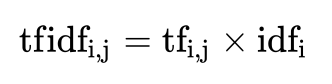

最终得出结果可以理解为重要程度。

```
注：假如一篇文件的总词语数是100个，而词语"非常"出现了5次，那么"非常"一词在该文件中的词频就是5/100=0.05。而计算文件频率（IDF）的方法是以文件集的文件总数，除以出现"非常"一词的文件数。所以，如果"非常"一词在1,0000份文件出现过，而文件总数是10,000,000份的话，其逆向文件频率就是lg（10,000,000 / 1,0000）=3。最后"非常"对于这篇文档的tf-idf的分数为0.05 * 3=0.15
```

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
import jieba

def cut_word(text):
    """
    对中文进行分词
    "我爱北京天安门"————>"我 爱 北京 天安门"
    :param text:
    :return: text
    """
    # 用结巴对中文字符串进行分词
    text = " ".join(list(jieba.cut(text)))

    return text

def text_chinese_tfidf_demo():
    """
    对中文进行特征抽取
    :return: None
    """
    data = ["一种还是一种今天很残酷，明天更残酷，后天很美好，但绝对大部分是死在明天晚上，所以每个人不要放弃今天。",
            "我们看到的从很远星系来的光是在几百万年之前发出的，这样当我们看到宇宙时，我们是在看它的过去。",
            "如果只用一种方式了解某样事物，你就不会真正了解它。了解事物真正含义的秘密取决于如何将其与我们所了解的事物相联系。"]
    # 将原始数据转换成分好词的形式
    text_list = []
    for sent in data:
        text_list.append(cut_word(sent))
    print(text_list)

    # 1、实例化一个转换器类
    # transfer = CountVectorizer(sparse=False)
    transfer = TfidfVectorizer(stop_words=['一种', '不会', '不要'])
    # 2、调用fit_transform
    data = transfer.fit_transform(text_list)
    print("文本特征抽取的结果：\n", data.toarray())
    print("返回特征名字：\n", transfer.get_feature_names())

    return None

In [20]:
text_chinese_tfidf_demo()

['一种 还是 一种 今天 很 残酷 ， 明天 更 残酷 ， 后天 很 美好 ， 但 绝对 大部分 是 死 在 明天 晚上 ， 所以 每个 人 不要 放弃 今天 。', '我们 看到 的 从 很 远 星系 来 的 光是在 几百万年 之前 发出 的 ， 这样 当 我们 看到 宇宙 时 ， 我们 是 在 看 它 的 过去 。', '如果 只用 一种 方式 了解 某样 事物 ， 你 就 不会 真正 了解 它 。 了解 事物 真正 含义 的 秘密 取决于 如何 将 其 与 我们 所 了解 的 事物 相 联系 。']
文本特征抽取的结果：
 [[0.         0.         0.         0.43643578 0.         0.
  0.         0.         0.         0.21821789 0.         0.21821789
  0.         0.         0.         0.         0.21821789 0.21821789
  0.         0.43643578 0.         0.21821789 0.         0.43643578
  0.21821789 0.         0.         0.         0.21821789 0.21821789
  0.         0.         0.21821789 0.        ]
 [0.2410822  0.         0.         0.         0.2410822  0.2410822
  0.2410822  0.         0.         0.         0.         0.
  0.         0.         0.2410822  0.55004769 0.         0.
  0.         0.         0.2410822  0.         0.         0.
  0.         0.48216441 0.         0.         0.         0.
  0.         0.2410822  0.         0.2410822 

**Tf-idf 是分类机器学习算法进行文章分类中前期数据处理方式**

## 特征预处理
什么是特征预处理？
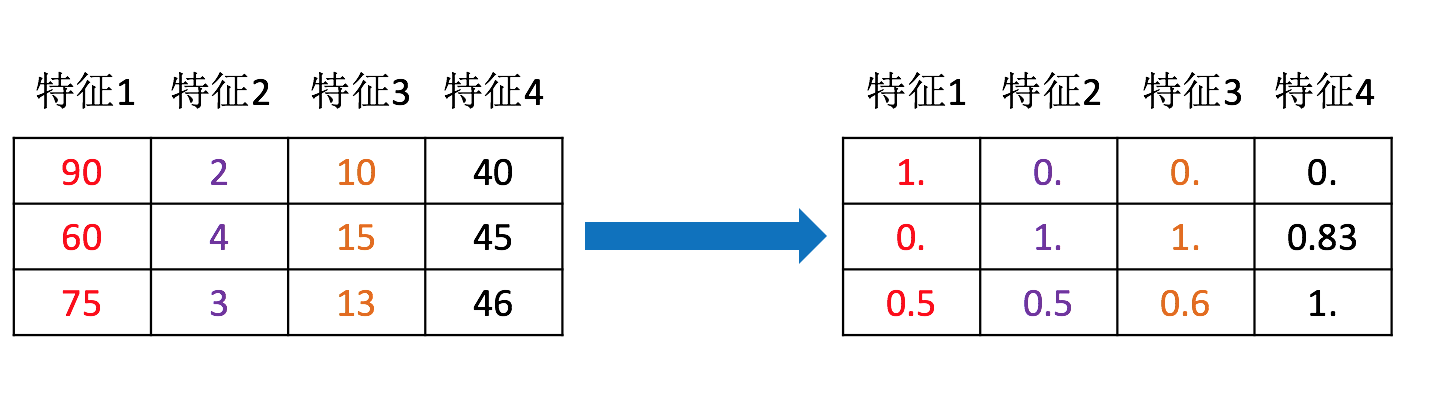

通过一些转换函数将特征数据转换成更加适合算法模型的特征数据过程！！

### 数值型数据的无量纲化

- 归一化
- 标准化

**为什么我们要进行归一化/标准化？**

特征的单位或者大小相差较大，或者某特征的方差相比其他的特征要大出几个数量级，容易影响（支配）目标结果，使得一些算法无法学习到其它的特征

### 特征预处理API
```
sklearn.preprocessing
```

### 归一化



**定义:**通过对原始数据进行变换把数据映射到(默认为[0,1])之间

**公式:**
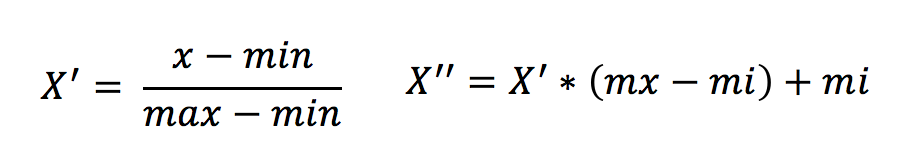

```
作用于每一列，max为一列的最大值，min为一列的最小值,那么X’’为最终结果，mx，mi分别为指定区间值默认mx为1,mi为0
```



那么怎么理解这个过程呢？我们通过一个例子:
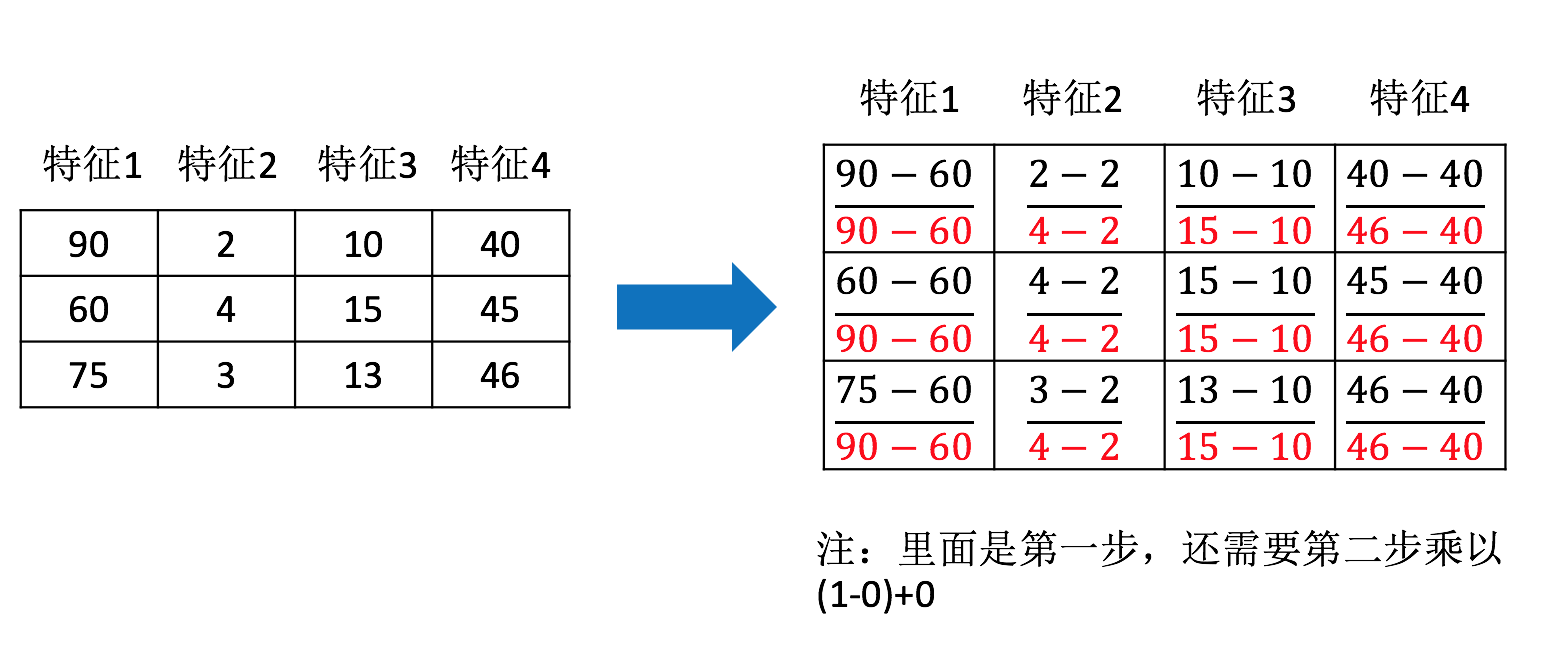

#### 归一化API
- sklearn.preprocessing.MinMaxScaler (feature_range=(0,1)… )
    - MinMaxScalar.fit_transform(X)
        - X:numpy array格式的数据[n_samples,n_features]
    - 返回值：转换后的形状相同的array
   


#### 案例实现
约会对象数据：
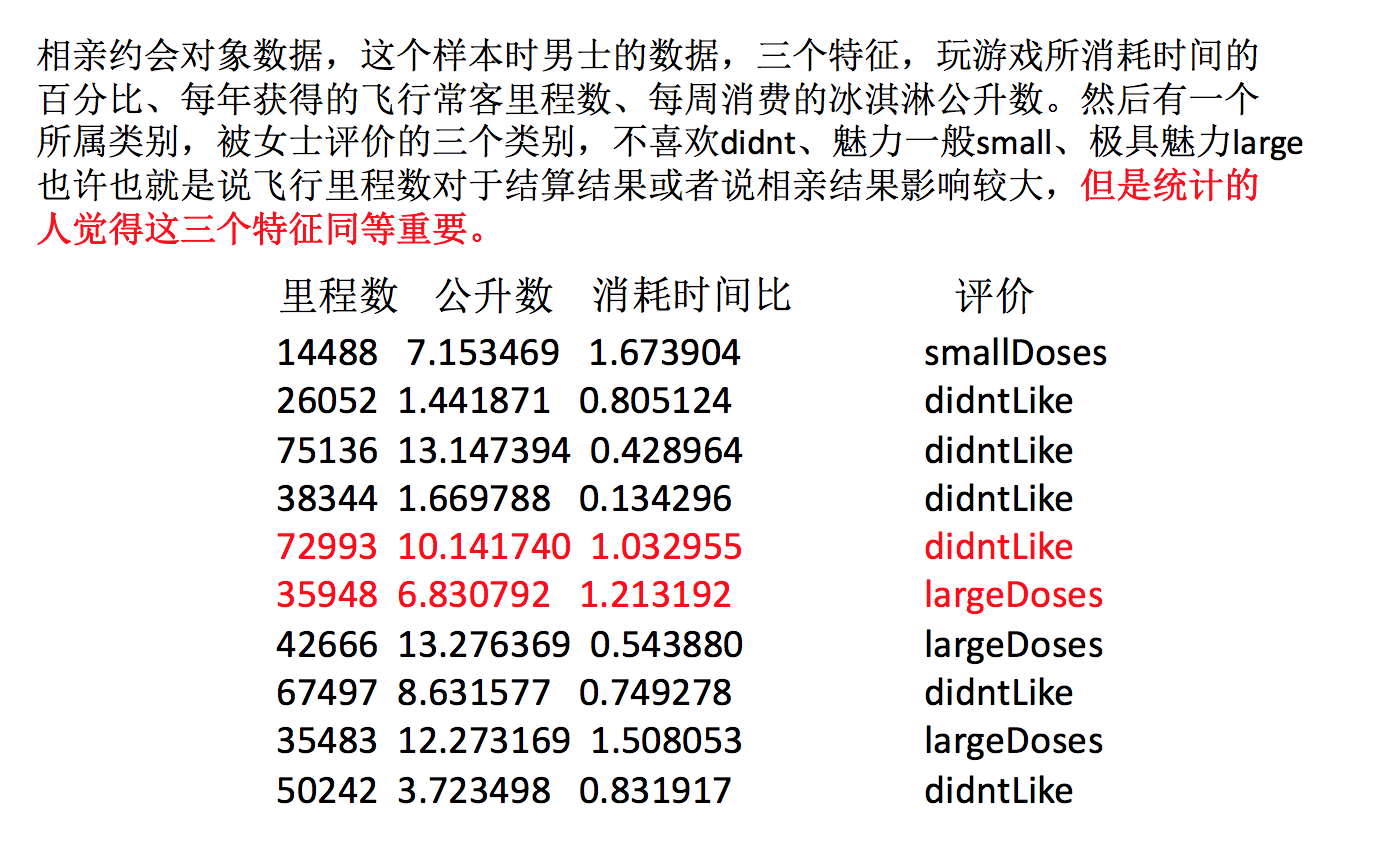

我们需要用到一些方法进行无量纲化，使不同规格的数据转换到同一规格。

我们对以下数据进行运算，在dating.txt中。保存的就是之前的约会对象数据：
```
milage,Liters,Consumtime,target
40920,8.326976,0.953952,3
14488,7.153469,1.673904,2
26052,1.441871,0.805124,1
75136,13.147394,0.428964,1
38344,1.669788,0.134296,1
```

1、实例化MinMaxScalar

2、通过fit_transform转换

In [21]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

def minmax_demo():
    """
    归一化演示
    :return: None
    """
    data = pd.read_csv("dating.txt")
    print(data)
    # 1、实例化一个转换器类
    transfer = MinMaxScaler(feature_range=(2, 3))
    # 2、调用fit_transform
    data = transfer.fit_transform(data[['milage','Liters','Consumtime']])
    print("最小值最大值归一化处理的结果：\n", data)

    return None

In [22]:
minmax_demo()

   milage     Liters  Consumtime  target
0   40920   8.326976    0.953952       3
1   14488   7.153469    1.673904       2
2   26052   1.441871    0.805124       1
3   75136  13.147394    0.428964       1
4   38344   1.669788    0.134296       1
最小值最大值归一化处理的结果：
 [[2.43582641 2.58819286 2.53237967]
 [2.         2.48794044 3.        ]
 [2.19067405 2.         2.43571351]
 [3.         3.         2.19139157]
 [2.3933518  2.01947089 2.        ]]


**问题：如果数据中异常点较多，会有什么影响？**

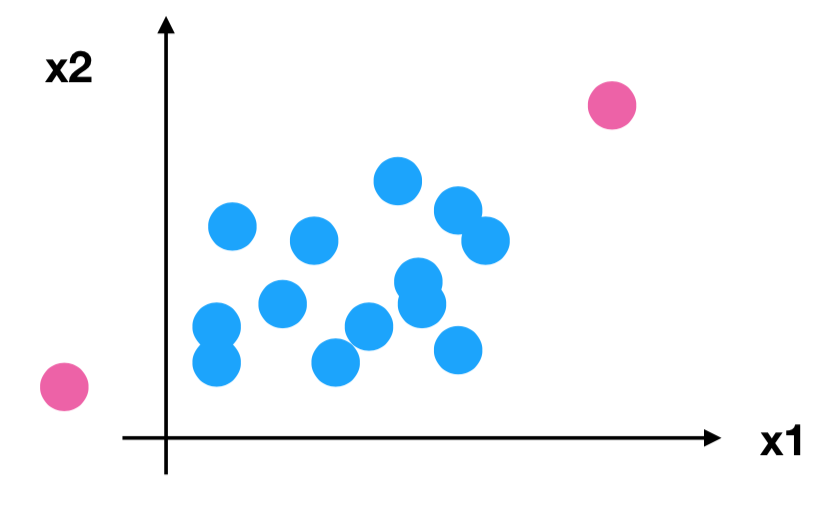

#### 归一化总结
注意最大值最小值是变化的，另外，最大值与最小值非常容易受异常点影响，所以这种方法鲁棒性较差，只适合传统精确小数据场景。

**怎么办？**

### 标准化

**定义：**通过对原始数据进行变换把数据变换到均值为0,标准差为1范围内

**公式：**
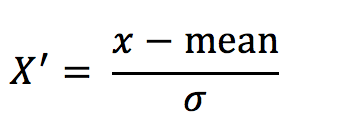
```
作用于每一列，mean为平均值，σ为标准差
```

所以回到刚才异常点的地方，我们再来看看标准化:
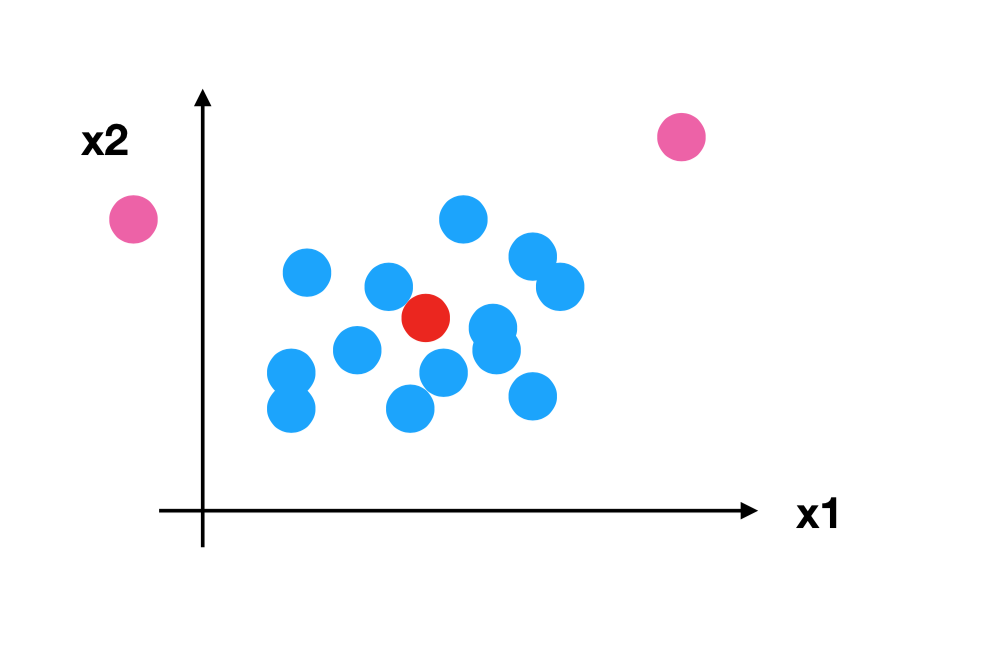

- 对于归一化来说：如果出现异常点，影响了最大值和最小值，那么结果显然会发生改变
- 对于标准化来说：如果出现异常点，由于具有一定数据量，少量的异常点对于平均值的影响并不大，从而方差改变较小。

**API**

- sklearn.preprocessing.StandardScaler( )
    - 处理之后每列来说所有数据都聚集在均值0附近标准差差为1
    - StandardScaler.fit_transform(X)
        - X:numpy array格式的数据[n_samples,n_features]
    - 返回值：转换后的形状相同的array

#### 数据计算

1、实例化StandardScaler

2、通过fit_transform转换

In [23]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

def stand_demo():
    """
    标准化演示
    :return: None
    """
    data = pd.read_csv("dating.txt")
    print(data)
    # 1、实例化一个转换器类
    transfer = StandardScaler()
    # 2、调用fit_transform
    data = transfer.fit_transform(data[['milage','Liters','Consumtime']])
    print("标准化的结果:\n", data)
    print("每一列特征的平均值：\n", transfer.mean_)
    print("每一列特征的方差：\n", transfer.var_)

    return None

In [24]:
stand_demo()

   milage     Liters  Consumtime  target
0   40920   8.326976    0.953952       3
1   14488   7.153469    1.673904       2
2   26052   1.441871    0.805124       1
3   75136  13.147394    0.428964       1
4   38344   1.669788    0.134296       1
标准化的结果:
 [[ 0.0947602   0.44990013  0.29573441]
 [-1.20166916  0.18312874  1.67200507]
 [-0.63448132 -1.11527928  0.01123265]
 [ 1.77297701  1.54571769 -0.70784025]
 [-0.03158673 -1.06346729 -1.27113187]]
每一列特征的平均值：
 [3.8988000e+04 6.3478996e+00 7.9924800e-01]
每一列特征的方差：
 [4.15683072e+08 1.93505309e+01 2.73652475e-01]


#### 标准化总结
在已有样本足够多的情况下比较稳定，适合现代嘈杂大数据场景。